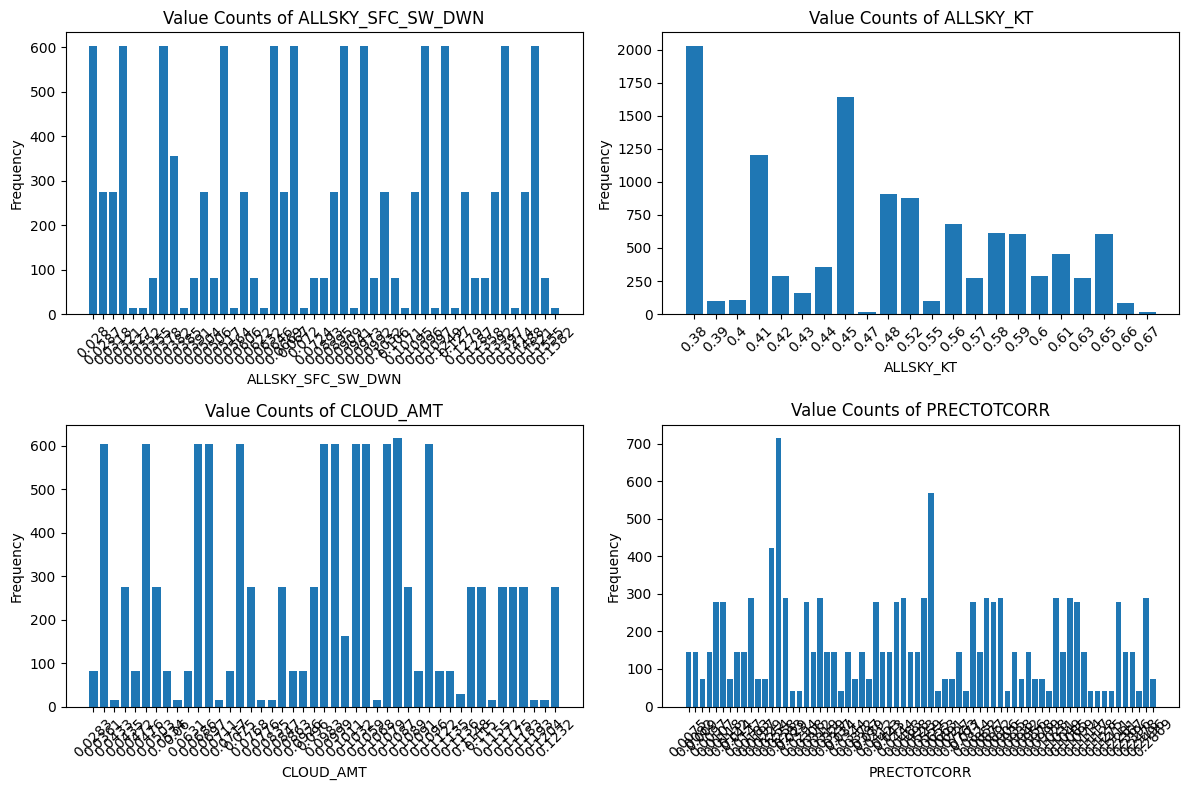

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = 'nasa_2023_only_l2_normalized_scaled.csv'
data = pd.read_csv(file_path)

# Columns to visualize
columns_to_visualize = ['ALLSKY_SFC_SW_DWN', 'ALLSKY_KT', 'CLOUD_AMT', 'PRECTOTCORR']

# Plot the value counts (bar plot) for each column
plt.figure(figsize=(12, 8))
for i, col in enumerate(columns_to_visualize, 1):
    att_counts = data[col].value_counts().sort_index()
    plt.subplot(2, 2, i)  # Create a 2x2 grid of subplots
    plt.bar(range(len(att_counts)), att_counts.values)
    plt.xticks(range(len(att_counts)), att_counts.index, rotation=45)
    plt.title(f"Value Counts of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [22]:
import pandas as pd

# Load the CSV
df = pd.read_csv("nasa_2023_only.csv")

# Show count of unique values for each column
unique_counts = df.nunique()
print("Unique value counts:\n", unique_counts, "\n")

# Show min, max, mean for each numeric column
summary_stats = df.describe().loc[['min', 'max', 'mean']]
print("Summary statistics (min, max, mean):\n", summary_stats)


Unique value counts:
 lat                  39
lon                  64
date                 12
ALLSKY_SFC_SW_DWN    48
ALLSKY_KT            22
CLOUD_AMT            47
PRECTOTCORR          68
dtype: int64 

Summary statistics (min, max, mean):
            lat        lon      date  ALLSKY_SFC_SW_DWN  ALLSKY_KT  CLOUD_AMT  \
min   40.82000  28.000000  202301.0           4.820000   0.380000  18.660000   
max   41.58000  29.890000  202312.0          27.200000   0.670000  81.400000   
mean  41.15406  28.804296  202306.5          14.287616   0.489394  58.681261   

      PRECTOTCORR  
min       0.21000  
max       8.01000  
mean      1.93201  


## Normalizing data


In [25]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('nasa_2023_only.csv')

# Columns to normalize
columns_to_normalize = ['ALLSKY_SFC_SW_DWN',  'CLOUD_AMT', 'PRECTOTCORR']

# Apply L2 normalization and round to 4 decimals
for col in columns_to_normalize:
    norm = np.linalg.norm(df[col])
    if norm != 0:
        df[f'{col}_norm'] = (df[col] / norm).round(5)
    else:
        df[f'{col}_norm'] = df[col].round(6)  # If norm is zero, just round original

# Save to new CSV
df.to_csv('nasa_2023_only_l2_normalized.csv', index=False)

print("Saved L2-normalized and rounded data to 'nasa_2023_only_l2_normalized.csv'")


Saved L2-normalized and rounded data to 'nasa_2023_only_l2_normalized.csv'


## Scaling data

In [26]:
import pandas as pd

# Load the L2-normalized data
df = pd.read_csv('nasa_2023_only_l2_normalized.csv')

# Columns to scale
columns_to_scale = ['CLOUD_AMT_norm', 'PRECTOTCORR_norm']

# Create a new DataFrame to hold only the needed columns
new_df = pd.DataFrame()

# Add the unscaled ALLSKY_KT_norm
new_df['lat'] = df['lat']
new_df['lon']=df['lon']
new_df['ALLSKY_SFC_SW_DWN'] = (df['ALLSKY_SFC_SW_DWN_norm'] * 10).round(4)
new_df['ALLSKY_KT'] = df['ALLSKY_KT']
new_df['CLOUD_AMT'] = (df['CLOUD_AMT_norm'] * 10).round(4)
new_df['PRECTOTCORR'] = (df['PRECTOTCORR_norm'] * 10).round(4)



# Save to a new CSV
new_df.to_csv('nasa_2023_only_l2_normalized_scaled.csv', index=False)

print("Saved scaled normalized data (×10) to 'nasa_annual_summary_l2_normalized_scaled.csv'")


Saved scaled normalized data (×10) to 'nasa_annual_summary_l2_normalized_scaled.csv'
